## Predictions : comparing with the true

In [1]:
### autoreloader
%load_ext autoreload
%autoreload 2

In [2]:
### setting up the system path
import sys
sys.path.append('../')

In [6]:
### importing the functions from the src file
from src.data.load_data import load_data, get_info, get_nan, get_shape, drop_col
from src.predictions.predictions_plot import best_model_predict_valid, compare_models_on_valid

In [14]:
### setting up the data paths
valid_distance_path = '../data/model_ready/valid_distance.csv'
valid_tree_path = '../data/model_ready/valid_tree.csv'
y_true_valid_path = '../data/split/y_true_valid.csv'

In [9]:
### loading the 'valid_distance' 
valid_distance = load_data(valid_distance_path)
valid_distance.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,Merchant_Category_Groceries,Merchant_Category_Restaurants,Merchant_Category_Travel,Card_Type_Discover,Card_Type_Mastercard,Card_Type_Visa,Authentication_Method_OTP,Authentication_Method_PIN,Authentication_Method_Password,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0.012998,0,0,0.076923,0.694722,0.75,0.894958,0.913818,0.686537,1,0.090909,0.300000,0.086957,0.265145
1,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0.463744,0,1,0.769231,0.075779,0.25,0.323529,0.059363,0.532206,1,0.181818,0.833333,0.956522,0.371321
2,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0.801443,0,0,0.461538,0.306400,0.50,0.243697,0.958614,0.492398,0,0.636364,0.133333,0.521739,0.324475
3,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0.242247,0,0,0.153846,0.674252,1.00,0.596639,0.663668,0.550310,0,0.000000,0.700000,0.826087,0.336945
4,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0.267799,1,0,0.000000,0.285297,0.00,0.949580,0.114540,0.220744,0,0.636364,0.633333,0.521739,0.407352


In [11]:
### checking the shape
get_shape(valid_distance)

(10000, 33)

In [10]:
### loading the 'valid_tree'
valid_tree = load_data(valid_tree_path)
valid_tree.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,Merchant_Category_Groceries,Merchant_Category_Restaurants,Merchant_Category_Travel,Card_Type_Discover,Card_Type_Mastercard,Card_Type_Visa,Authentication_Method_OTP,Authentication_Method_PIN,Authentication_Method_Password,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour
0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,19.98,1804.81,0,0,2,350.41,3,214,4568.48,0.6865,1,2,10,2
1,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,45.32,46648.03,0,1,11,47.14,1,78,297.39,0.5322,1,3,26,22
2,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,32.25,80244.56,0,0,7,160.14,2,59,4792.40,0.4924,0,8,5,12
3,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,0,1,0,0,35.41,24611.99,0,0,3,340.38,4,143,3318.08,0.5503,0,1,22,19
4,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,57.80,27154.09,1,0,1,149.80,0,227,573.20,0.2208,0,8,20,12


In [12]:
### dropping the 'Failed_Transaction_Count_7d' (check the misc.md file in the docs)
drop_col(valid_tree, 'Failed_Transaction_Count_7d')
valid_tree.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,Merchant_Category_Groceries,Merchant_Category_Restaurants,Merchant_Category_Travel,Card_Type_Discover,Card_Type_Mastercard,Card_Type_Visa,Authentication_Method_OTP,Authentication_Method_PIN,Authentication_Method_Password,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour
0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,19.98,1804.81,0,0,2,350.41,214,4568.48,0.6865,1,2,10,2
1,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,45.32,46648.03,0,1,11,47.14,78,297.39,0.5322,1,3,26,22
2,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,32.25,80244.56,0,0,7,160.14,59,4792.40,0.4924,0,8,5,12
3,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,0,1,0,0,35.41,24611.99,0,0,3,340.38,143,3318.08,0.5503,0,1,22,19
4,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,57.80,27154.09,1,0,1,149.80,227,573.20,0.2208,0,8,20,12


In [13]:
### checking the shape now
get_shape(valid_tree)

(10000, 32)

In [ ]:
### loading the y_true_valid
y_true_valid = load_data(y_true_valid_path)
y_true_valid.head()

,Fraud_Label
0,0
1,0
2,0
3,1
4,0


In [16]:
### checking the shape
get_shape(y_true_valid)

(10000, 1)

In [17]:
### setting up the best model path for the distance 'SVC'
svc_path = '../models/distance/svc.pkl'

In [19]:
### predictions on valid_distance
y_pred_best_distance = best_model_predict_valid(valid_distance, best_model_path = svc_path)
y_pred_best_distance

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [23]:
### setting up the best model path for the trees 'Random forest'
rfc_path = '../models/tree/rfc.pkl'

In [24]:
### predictions on valid_tree
y_pred_best_tree = best_model_predict_valid(valid_tree, best_model_path = rfc_path)
y_pred_best_tree

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

Accuracy score : 0.7849
Confusion matrix : 
[[6478  153]
 [1998 1371]]
              precision    recall  f1-score   support

           0       0.76      0.98      0.86      6631
           1       0.90      0.41      0.56      3369

    accuracy                           0.78     10000
   macro avg       0.83      0.69      0.71     10000
weighted avg       0.81      0.78      0.76     10000



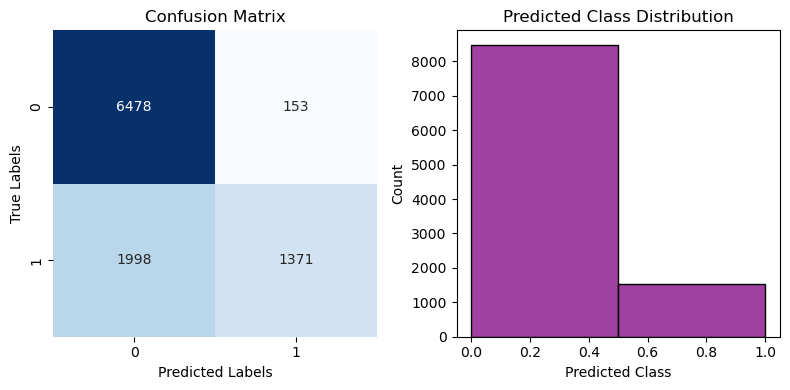

Accuracy score : 0.7849
Confusion matrix : 
[[6478 1998]
 [ 153 1371]]
              precision    recall  f1-score   support

           0       0.98      0.76      0.86      8476
           1       0.41      0.90      0.56      1524

    accuracy                           0.78     10000
   macro avg       0.69      0.83      0.71     10000
weighted avg       0.89      0.78      0.81     10000



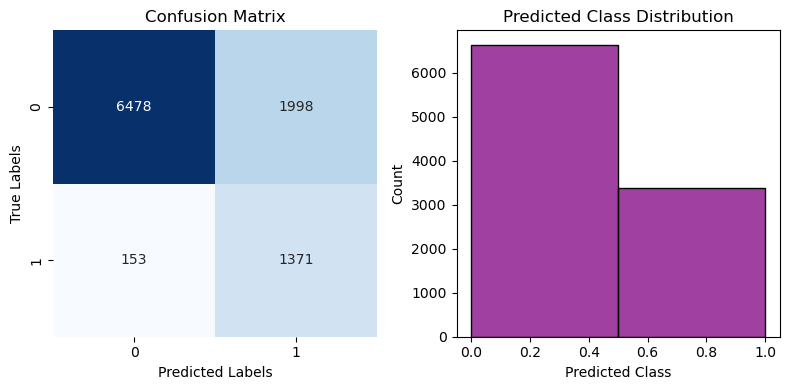

Accuracy score : 0.956
Confusion matrix : 
[[6478  153]
 [ 287 3082]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      6631
           1       0.95      0.91      0.93      3369

    accuracy                           0.96     10000
   macro avg       0.96      0.95      0.95     10000
weighted avg       0.96      0.96      0.96     10000



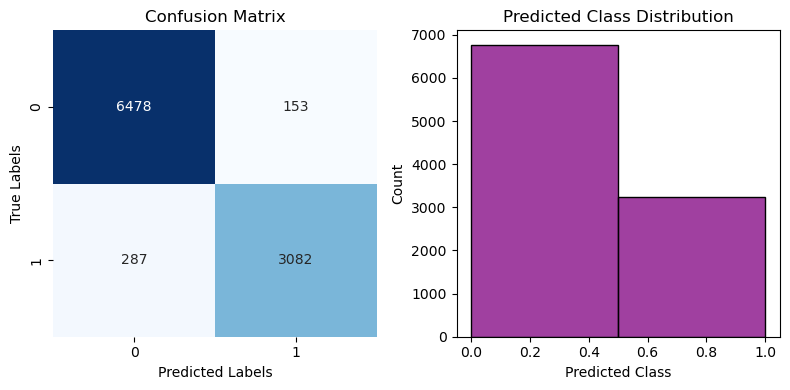

Accuracy score : 0.8289
Confusion matrix : 
[[6765 1711]
 [   0 1524]]
              precision    recall  f1-score   support

           0       1.00      0.80      0.89      8476
           1       0.47      1.00      0.64      1524

    accuracy                           0.83     10000
   macro avg       0.74      0.90      0.76     10000
weighted avg       0.92      0.83      0.85     10000



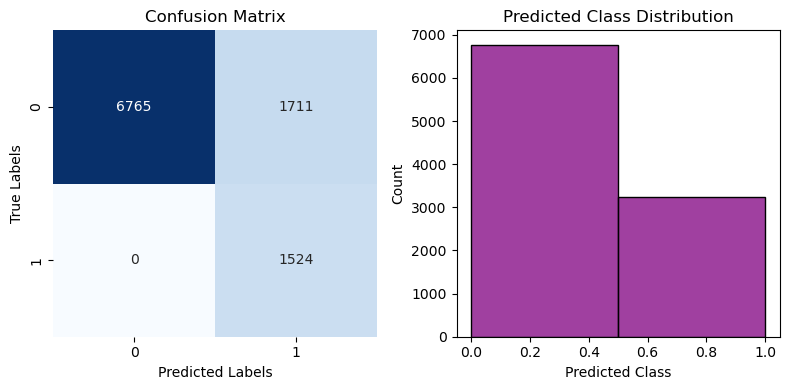

In [26]:
### comparing out the things with each other and 'y_true_valid'
compare_models_on_valid(y_pred_best_tree, y_pred_best_distance, y_true_valid['Fraud_Label'])